# GSADF (exuber) — Option (A): Python driver + R

GSADF is computed in **R** with [`exuber`](https://cran.r-project.org/package=exuber) (`radf`, `radf_mc_cv`, `datestamp`).  
This notebook **does not** reimplement GSADF in Python; it **calls** `R/codes_R/gsadf_exuber_master_prep.R` via `Rscript`, then loads `R/df_master_gsadf.csv` for checks and plots.

**Prerequisites**

1. **R** installed, with `Rscript` on your `PATH` (or set `RSCRIPT` in the first code cell to the full path of `Rscript.exe`).
2. R packages: `tidyverse`, `exuber`, `here` (install in R: `install.packages(c("tidyverse","exuber","here"))`).
3. An existing master file: **`R/data_R/df_master.csv`** (preferred) or `R/df_master.csv` (from `metals30_data_prep.R`).

**First run** may take a little time while `radf_mc_cv` is simulated; results are cached under `outputs/R_objects/`.

## Step 1 — Repo root and path to the R script

Run the notebook from the **metals** project workspace (so we can find `R/` and `data/`).

**Python kernel:** use the same environment you use for the other analysis notebooks (e.g. `lppls_data_prep`) — any **Python 3.10+** with `pandas` and `matplotlib` is enough. This notebook does **not** need R inside Python; it only calls `Rscript` on the side.

**Order:** run this Step 1 cell before Step 2. After **Restart kernel**, run Step 1 again.

In [3]:
import glob
import os
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root() -> Path:
    """Walk up from cwd until we see R/codes_R and data/."""
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "R" / "codes_R").is_dir() and (p / "data").is_dir():
            return p
        p = p.parent
    return Path.cwd().resolve()


def find_rscript() -> str | None:
    """Resolve Rscript: env RSCRIPT, then PATH, then common Windows install folders."""
    env = os.environ.get("RSCRIPT", "").strip().strip('"')
    if env and Path(env).is_file():
        return env
    for name in ("Rscript", "Rscript.exe"):
        w = shutil.which(name)
        if w and Path(w).is_file():
            return w
    if os.name == "nt":
        patterns = [
            r"C:\Program Files\R\R-*\bin\Rscript.exe",
            r"C:\Program Files (x86)\R\R-*\bin\Rscript.exe",
        ]
        found: list[str] = []
        for pat in patterns:
            found.extend(glob.glob(pat))
        for exe in sorted(found, key=lambda s: s.lower(), reverse=True):
            if Path(exe).is_file():
                return exe
    return None


REPO_ROOT = find_repo_root()
R_SCRIPT = REPO_ROOT / "R" / "codes_R" / "gsadf_exuber_master_prep.R"

# If auto-detect fails, set the full path here (use your installed version folder):
# os.environ["RSCRIPT"] = r"C:\Program Files\R\R-4.4.2\bin\Rscript.exe"

RSCRIPT = find_rscript()

print("REPO_ROOT:", REPO_ROOT)
print("R script exists:", R_SCRIPT.is_file(), "→", R_SCRIPT)
print("Rscript:", RSCRIPT or "NOT FOUND")
if not RSCRIPT:
    print(
        "\nFix: (1) Install R from https://cran.r-project.org/bin/windows/base/\n"
        "     (2) In Explorer open C:\\Program Files\\R\\ and note the folder R-x.y.z\n"
        "     (3) Uncomment os.environ['RSCRIPT'] in this cell and set ...\\R-x.y.z\\bin\\Rscript.exe\n"
        "     Or add that bin folder to Windows PATH and restart Cursor."
    )

REPO_ROOT: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals
R script exists: True → C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\codes_R\gsadf_exuber_master_prep.R
Rscript: C:\Program Files\R\R-4.3.3\bin\Rscript.exe


## Step 2 — Run exuber prep in R

This writes **`R/df_master_gsadf.csv`** (same `csv2` layout as `df_master.csv`).  
Console output from R is streamed below.

In [7]:
if "RSCRIPT" not in globals() or "REPO_ROOT" not in globals():
    raise RuntimeError(
        "Run the Step 1 code cell above first (it defines RSCRIPT, REPO_ROOT, R_SCRIPT). "
        "If you restarted the kernel, re-run Step 1 before Step 2."
    )

if not RSCRIPT:
    raise FileNotFoundError(
        "Rscript not found. Add R's bin folder to PATH or set os.environ['RSCRIPT'] to Rscript.exe"
    )
if not R_SCRIPT.is_file():
    raise FileNotFoundError(f"Missing R script: {R_SCRIPT}")

proc = subprocess.run(
    [RSCRIPT, str(R_SCRIPT)],
    cwd=str(REPO_ROOT),
    capture_output=True,
    text=True,
)
print(proc.stdout)
if proc.stderr:
    print("--- stderr ---\n", proc.stderr)
if proc.returncode != 0:
    raise RuntimeError(f"Rscript exited with code {proc.returncode}")

out_csv = REPO_ROOT / "R" / "df_master_gsadf.csv"
print("Output exists:", out_csv.is_file(), "→", out_csv)

renv 1.1.6 was loaded from project library, but this project is configured to use renv 1.1.6.
- Use `renv::record("renv@1.1.6")` to record renv 1.1.6 in the lockfile.
- Use `renv::restore(packages = "renv")` to install renv 1.1.6 into the project library.

NOTE: Dependency discovery took 38 seconds during snapshot.
Consider using .renvignore to ignore files, or switching to explicit snapshots.
See `?renv::dependencies` for more information.

- The project is out-of-sync -- use `renv::status()` for details.

--- stderr ---
 Using master: C:/Users/user/OneDrive - Uniwersytet Ekonomiczny w Poznaniu/Dokumenty/Publikacje/Metals/metals/R/data_R/df_master.csv
Panel: 2152 rows, 2017-05-10 â€” 2025-10-31
Loaded MC critical values: C:/Users/user/OneDrive - Uniwersytet Ekonomiczny w Poznaniu/Dokumenty/Publikacje/Metals/metals/outputs/R_objects/mc_cv_radf_n2152_minwDefault_seed123.rds

GSADF â€” upward (OLS episode filter), df_master_gsadf.csv:
  CODALY  :   135 days (6.3%)
  CUDALY  :    24 days 

## Step 3 — Load masters and compare bubble prevalence

`*_BD` in the **base** master (`R/data_R/df_master.csv` or `R/df_master.csv`) are your **previous** labels (typically from an earlier exuber run in `metals30_data_prep.R`).  
`*_BD` in `df_master_gsadf.csv` come from **`gsadf_exuber_master_prep.R`** (episode filter: OLS slope > 0 per `datestamp` interval — same idea as `metals30`).

If you change filtering in the R script, counts here will change.

In [8]:
def read_master(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";", decimal=",", index_col=0)
    df["Date"] = pd.to_datetime(df["Date"])
    return df.sort_values("Date").reset_index(drop=True)


candidates = [
    REPO_ROOT / "R" / "data_R" / "df_master.csv",
    REPO_ROOT / "R" / "df_master.csv",
]
base_path = next((p for p in candidates if p.is_file()), None)
if base_path is None:
    raise FileNotFoundError("No df_master.csv found under R/ or R/data_R/")

df_base = read_master(base_path)
df_new = read_master(out_csv)

metals = {"Cobalt": "CODALY", "Copper": "CUDALY", "Lithium": "LIDALY", "Nickel": "NIDALY"}

rows = []
for name, col in metals.items():
    b_old = df_base[col + "_BD"].astype(int)
    b_new = df_new[col + "_BD"].astype(int)
    rows.append(
        {
            "metal": name,
            "old_bd_days": int(b_old.sum()),
            "old_bd_pct": round(100 * b_old.mean(), 2),
            "new_bd_days": int(b_new.sum()),
            "new_bd_pct": round(100 * b_new.mean(), 2),
        }
    )

summary = pd.DataFrame(rows)
print("Base master:", base_path)
print("GSADF out:  ", out_csv)
display(summary)

Base master: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\data_R\df_master.csv
GSADF out:   C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\df_master_gsadf.csv


,metal,old_bd_days,old_bd_pct,new_bd_days,new_bd_pct
0,Cobalt,230,10.69,135,6.27
1,Copper,39,1.81,24,1.12
2,Lithium,1089,50.60,466,21.65
3,Nickel,26,1.21,11,0.51


## Step 4 — Quick timeline plot (price + new bubble shading)

Purple bands = `df_master_gsadf` `*_BD` == 1.

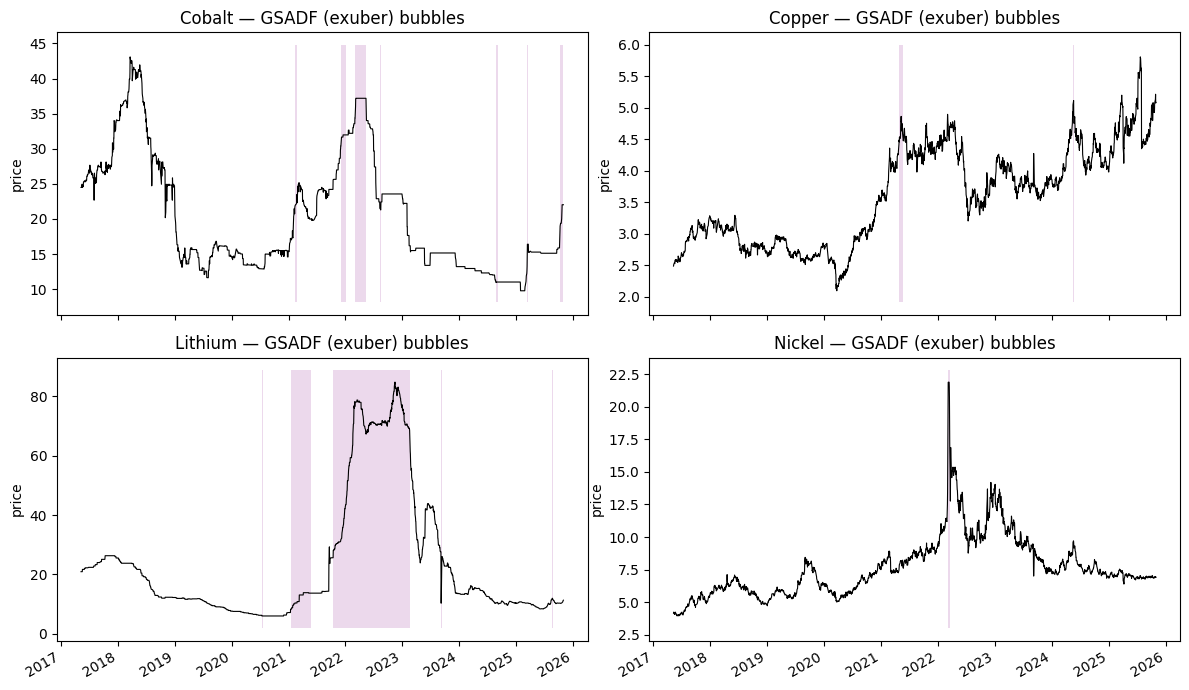

Saved: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\outputs\gsadf_exuber_timelines.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
for ax, (metal, col) in zip(axes, metals.items()):
    d = df_new["Date"].values
    p = df_new[col].astype(float).values
    bub = df_new[col + "_BD"].astype(int).values
    ax.plot(d, p, color="black", lw=0.8)
    if bub.any():
        ymin, ymax = ax.get_ylim()
        in_b = bub.astype(bool)
        ax.fill_between(d, ymin, ymax, where=in_b, color="purple", alpha=0.15, linewidth=0)
    ax.set_title(f"{metal} — GSADF (exuber) bubbles")
    ax.set_ylabel("price")
fig.autofmt_xdate()
fig.tight_layout()
out_png = REPO_ROOT / "outputs" / "gsadf_exuber_timelines.png"
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_png)